In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
hourly_df = pd.read_csv(
    "../../data/processed/hourly_device_energy.csv",
    parse_dates=["timestamp"]
)

hourly_df = hourly_df.set_index("timestamp")
hourly_df.head()


,Appliance Type,Energy Consumption (kWh)
timestamp,,
2023-01-01 00:00:00,Air Conditioning,4.42
2023-01-01 01:00:00,Air Conditioning,7.61
2023-01-01 02:00:00,Air Conditioning,14.80
2023-01-01 03:00:00,Air Conditioning,4.19
2023-01-01 04:00:00,Air Conditioning,10.68


In [4]:
# Detect unique appliances
appliances = hourly_df["Appliance Type"].unique()
print(f"Detected appliances: {appliances}")


Detected appliances: ['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [12]:
data_path = "../../data/model_inputs/"

files = os.listdir(data_path)

appliances = sorted({
    f.replace("X_train_", "").replace(".csv", "")
    for f in files if f.startswith("X_train_")
})

print("Appliances used for modeling:", appliances)


Appliances used for modeling: ['Air Conditioning', 'Computer', 'Dishwasher', 'Fridge', 'Heater', 'Lights', 'Microwave', 'Oven', 'TV', 'Washing Machine']



Training Linear Regression for: Air Conditioning
MAE  : 2.8536
RMSE : 3.5977


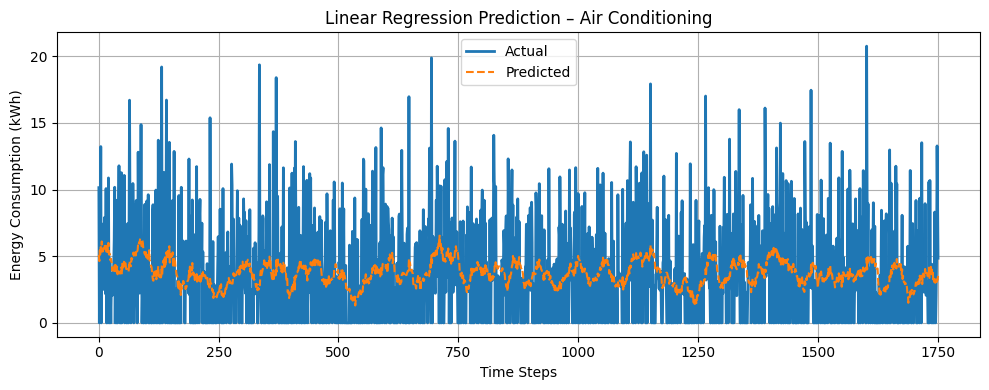


Training Linear Regression for: Computer
MAE  : 0.9917
RMSE : 1.2378


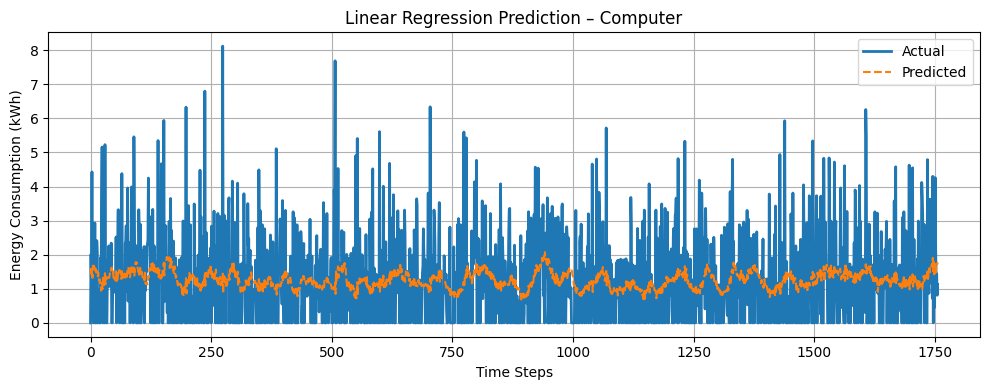


Training Linear Regression for: Dishwasher
MAE  : 1.0400
RMSE : 1.2991


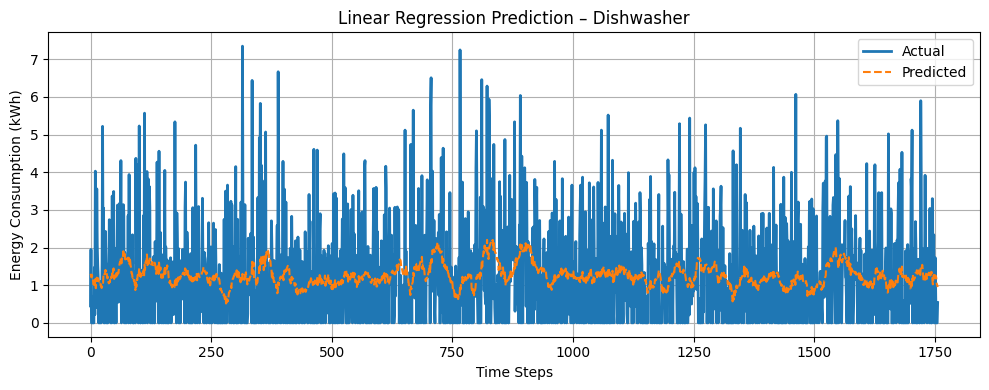


Training Linear Regression for: Fridge
MAE  : 0.2736
RMSE : 0.3389


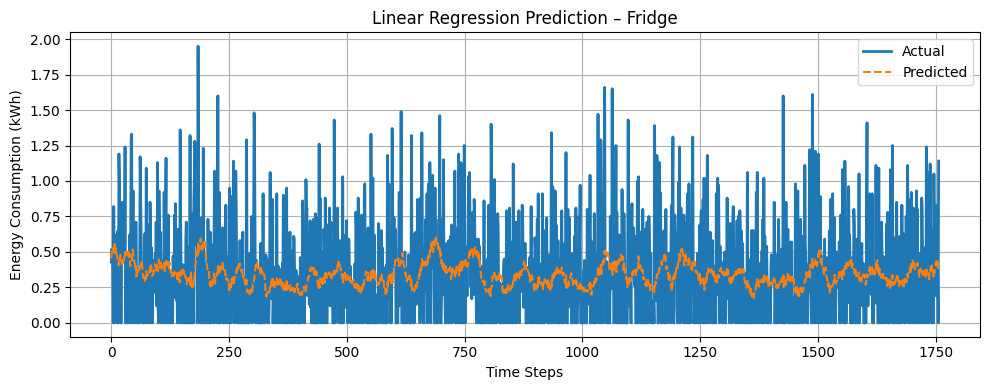


Training Linear Regression for: Heater
MAE  : 2.7455
RMSE : 3.4523


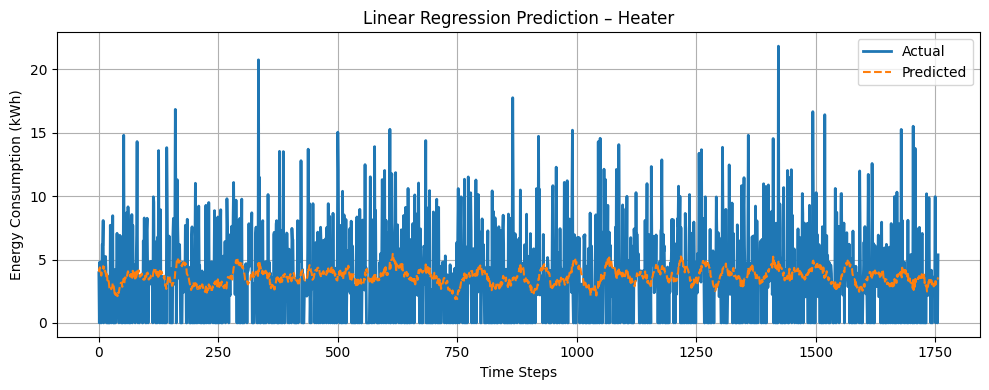


Training Linear Regression for: Lights
MAE  : 0.9817
RMSE : 1.2081


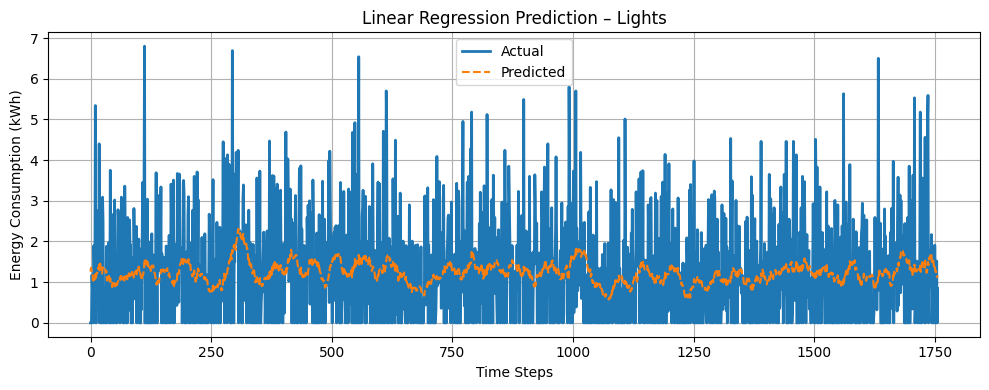


Training Linear Regression for: Microwave
MAE  : 1.0149
RMSE : 1.2794


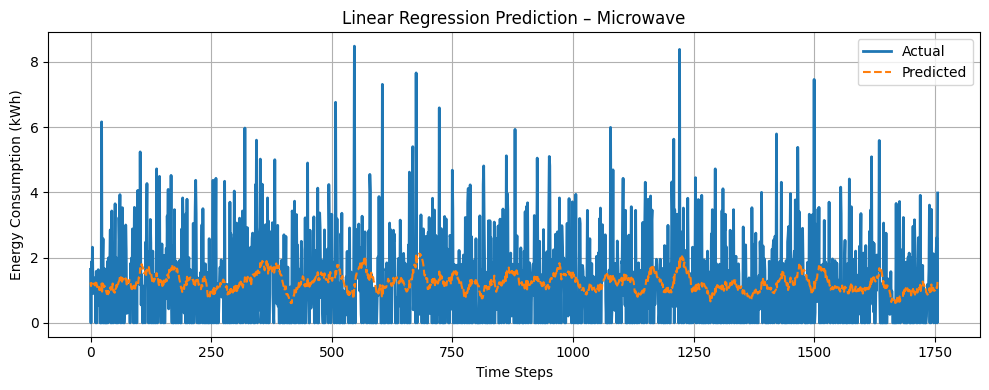


Training Linear Regression for: Oven
MAE  : 1.0286
RMSE : 1.2868


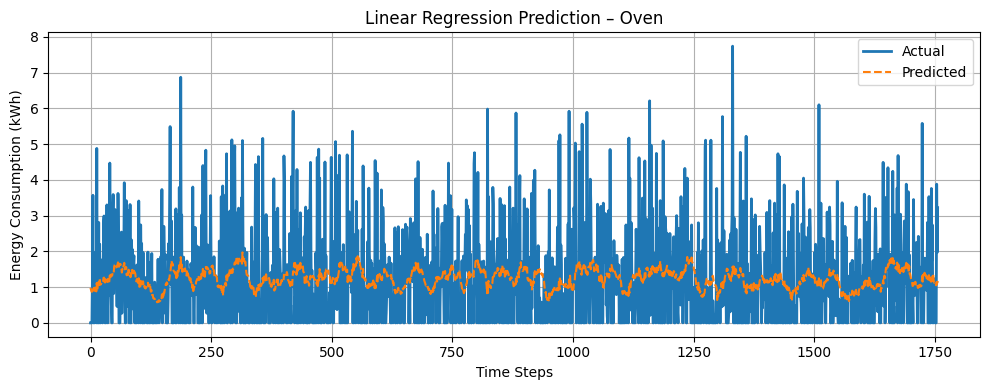


Training Linear Regression for: TV
MAE  : 0.9987
RMSE : 1.2408


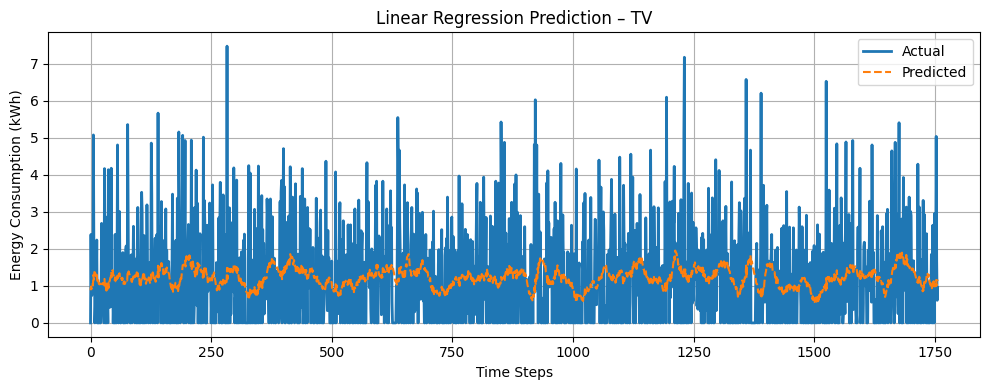


Training Linear Regression for: Washing Machine
MAE  : 0.9814
RMSE : 1.2227


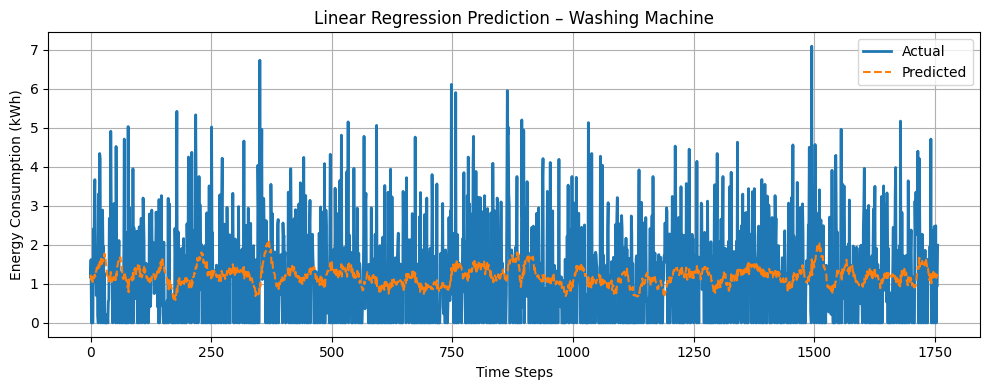

,Appliance,MAE,RMSE
0,Air Conditioning,2.853608,3.597696
1,Computer,0.991654,1.237802
2,Dishwasher,1.040021,1.299050
3,Fridge,0.273553,0.338950
4,Heater,2.745520,3.452303
5,Lights,0.981745,1.208070
6,Microwave,1.014921,1.279435
7,Oven,1.028588,1.286755
8,TV,0.998717,1.240846
9,Washing Machine,0.981406,1.222666


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define and create models directory
model_dir = "../../models"
os.makedirs(model_dir, exist_ok=True)

results = []

for appliance in appliances:
    print(f"\nTraining Linear Regression for: {appliance}")

    # Load data
    X_train = pd.read_csv(f"{data_path}X_train_{appliance}.csv")
    X_test  = pd.read_csv(f"{data_path}X_test_{appliance}.csv")

    y_train = pd.read_csv(
        f"{data_path}y_train_{appliance}.csv"
    ).values.ravel()

    y_test = pd.read_csv(
        f"{data_path}y_test_{appliance}.csv"
    ).values.ravel()

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    # Visualization
    plt.figure(figsize=(10,4))
    plt.plot(y_test, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--")
    plt.title(f"Linear Regression Prediction – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Safe filename
    safe_name = appliance.replace(" ", "_")

    # Save model
    joblib.dump(
        model,
        f"{model_dir}/linear_regression_{safe_name}.pkl"
    )

# Summary table
results_df = pd.DataFrame(results)
results_df


In [18]:
experiment_results = []

for appliance in appliances:
    X_train = pd.read_csv(f"{data_path}X_train_{appliance}.csv")
    X_test  = pd.read_csv(f"{data_path}X_test_{appliance}.csv")

    # Controlled modification
    if "day" in X_train.columns:
        X_train = X_train.drop(columns=["day"])
        X_test = X_test.drop(columns=["day"])

    y_train = pd.read_csv(
        f"{data_path}y_train_{appliance}.csv"
    ).values.ravel()

    y_test = pd.read_csv(
        f"{data_path}y_test_{appliance}.csv"
    ).values.ravel()

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    experiment_results.append({
        "Appliance": appliance,
        "MAE_without_day": mae,
        "RMSE_without_day": rmse
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df

,Appliance,MAE_without_day,RMSE_without_day
0,Air Conditioning,2.854110,3.597796
1,Computer,0.991441,1.237786
2,Dishwasher,1.039549,1.298895
3,Fridge,0.273465,0.338923
4,Heater,2.746197,3.452281
5,Lights,0.981498,1.207995
6,Microwave,1.015233,1.279471
7,Oven,1.028465,1.286686
8,TV,0.998860,1.240819
9,Washing Machine,0.981789,1.222689


In [6]:
# --- Feature Engineering (REQUIRED before modeling) ---

hourly_df["hour"] = hourly_df.index.hour
hourly_df["day"] = hourly_df.index.day
hourly_df["weekday"] = hourly_df.index.weekday
hourly_df["month"] = hourly_df.index.month

hourly_df["lag_1"] = hourly_df["Energy Consumption (kWh)"].shift(1)
hourly_df["lag_24"] = hourly_df["Energy Consumption (kWh)"].shift(24)

hourly_df["rolling_mean_24"] = (
    hourly_df["Energy Consumption (kWh)"]
    .rolling(window=24)
    .mean()
)

hourly_df = hourly_df.dropna()


In [7]:
hourly_df.columns


Index(['Appliance Type', 'Energy Consumption (kWh)', 'hour', 'day', 'weekday',
       'month', 'lag_1', 'lag_24', 'rolling_mean_24'],
      dtype='object')

In [8]:
FEATURE_COLUMNS = [
    "hour",
    "day",
    "weekday",
    "month",
    "lag_1",
    "lag_24",
    "rolling_mean_24"
]


In [9]:
appliances = hourly_df["Appliance Type"].unique()

results = []
models = {}


In [10]:
import os

os.makedirs("../models", exist_ok=True)



Training model for: Air Conditioning


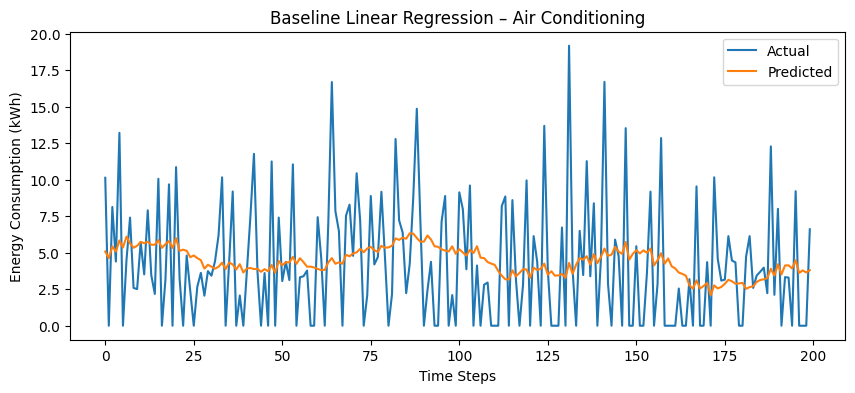


Training model for: Computer


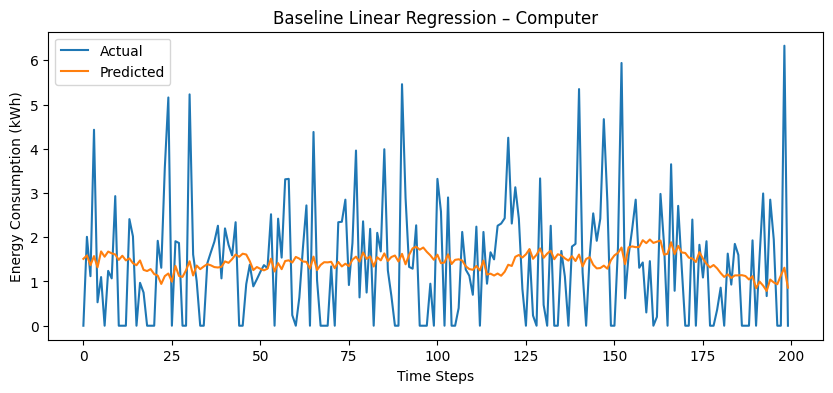


Training model for: Dishwasher


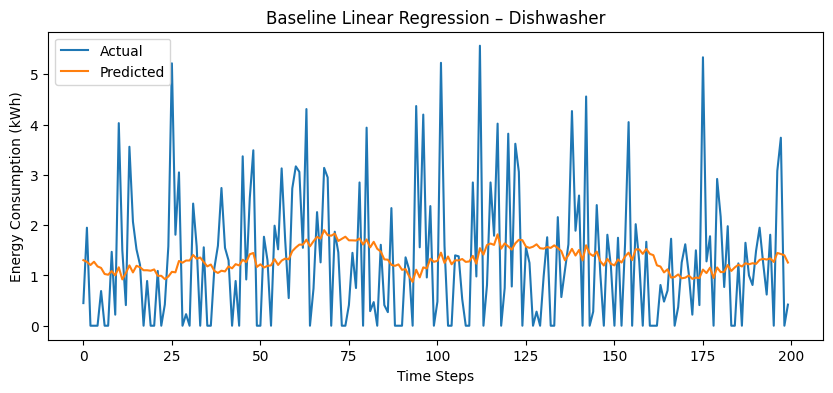


Training model for: Fridge


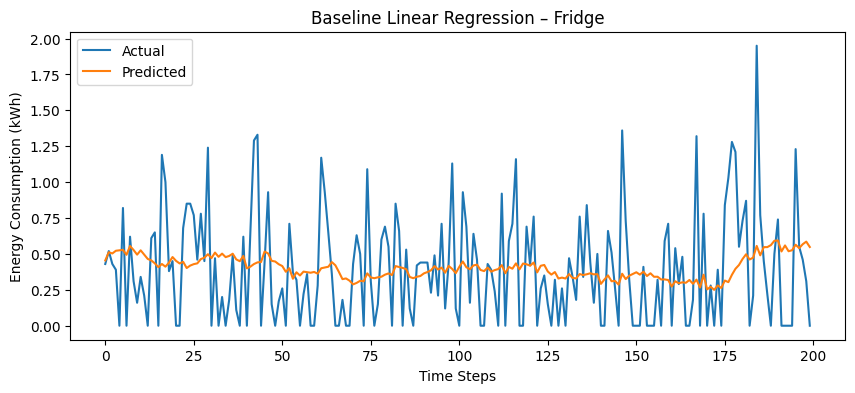


Training model for: Heater


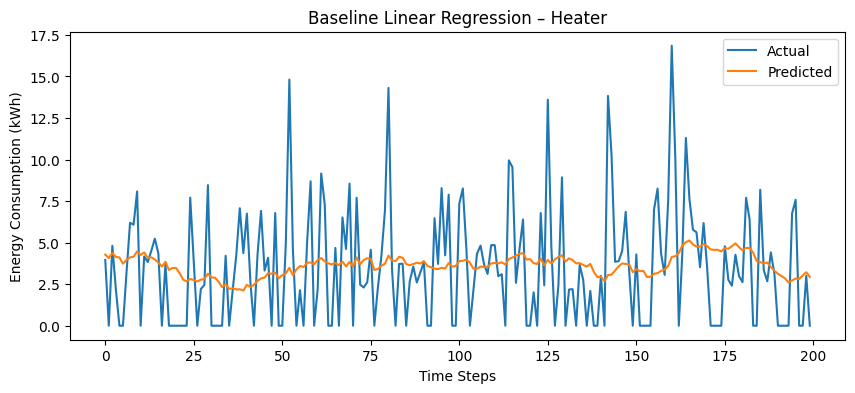


Training model for: Lights


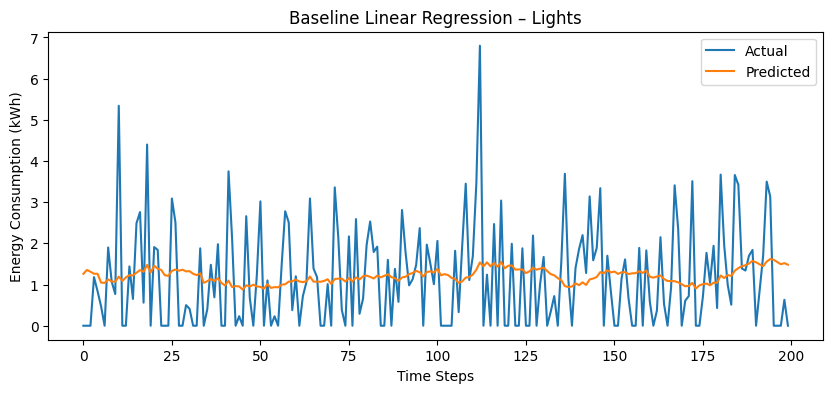


Training model for: Microwave


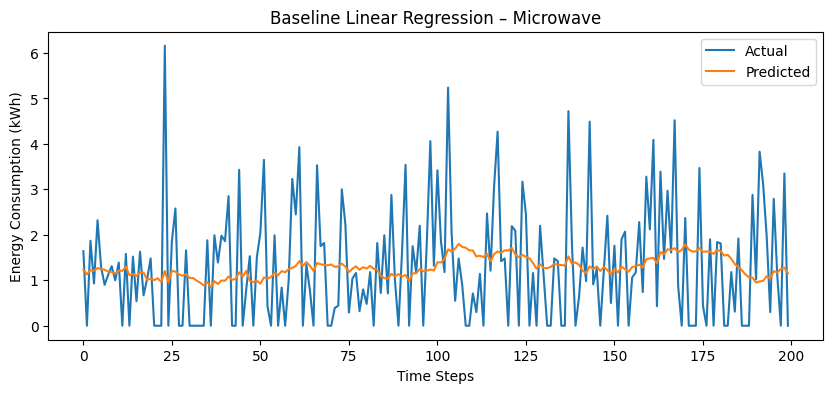


Training model for: Oven


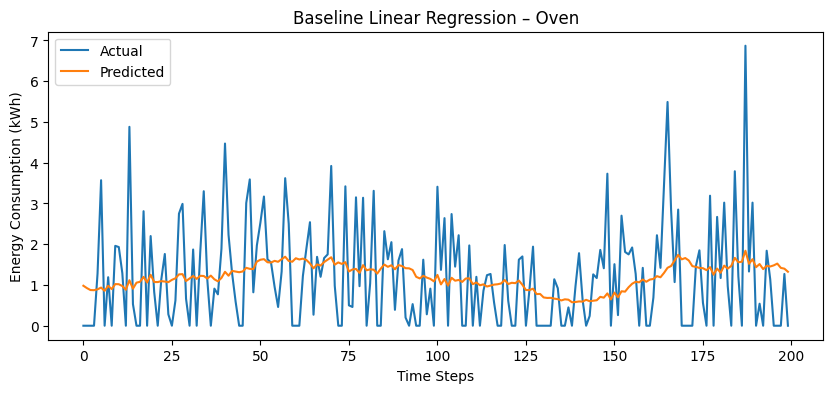


Training model for: TV


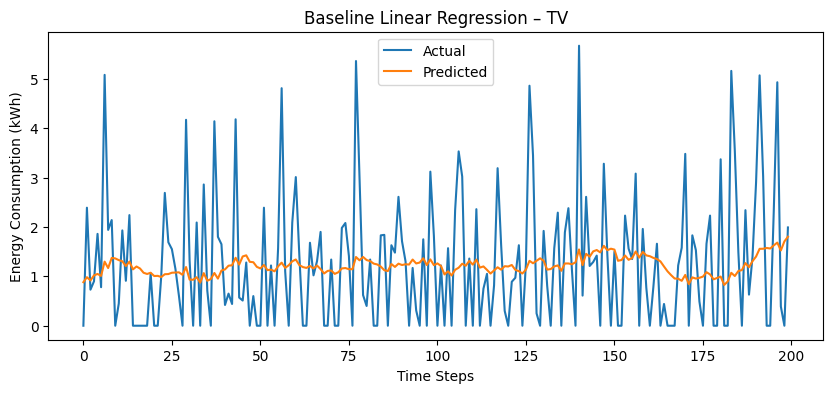


Training model for: Washing Machine


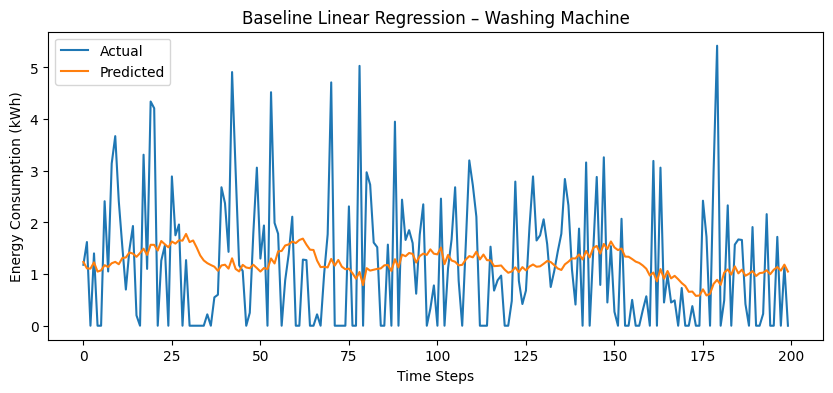

In [11]:
for appliance in appliances:
    print(f"\nTraining model for: {appliance}")

    appliance_df = hourly_df[
        hourly_df["Appliance Type"] == appliance
    ].copy()

    X = appliance_df[FEATURE_COLUMNS]
    y = appliance_df["Energy Consumption (kWh)"]

    # 80–20 time-based split
    split_index = int(len(X) * 0.8)

    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    models[appliance] = model

    # REQUIRED PLOT
    plt.figure(figsize=(10,4))
    plt.plot(y_test.values[:200], label="Actual")
    plt.plot(y_pred[:200], label="Predicted")
    plt.title(f"Baseline Linear Regression – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.show()

    # Save model
    safe_appliance = appliance.replace(" ", "_")

    joblib.dump(
        model,
        f"../models/linear_regression_{safe_appliance}.pkl"
    )

